In [15]:
import pandas as pd
import networkx as nx
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [48]:

nodes = pd.read_csv('../input/attributes.csv', header=0, names=['id', 'attribute'])
edges = pd.read_csv('../input/edges_train.edgelist', header=None, names=['id_1', 'id_2'])
edges = (edges.merge(nodes.rename(columns={'id': 'id_1', 'attribute': 'attribute_1'}), how='left')
              .merge(nodes.rename(columns={'id': 'id_2', 'attribute': 'attribute_2'}), how='left'))
nodes.set_index('id', inplace=True)

In [34]:
G = nx.read_edgelist('../input/edges_train.edgelist', delimiter=',', create_using=nx.Graph(), nodetype=int)
G.edges()

EdgeView([(0, 49), (0, 10), (0, 155), (0, 1489), (0, 275), (49, 484), (49, 503), (49, 1655), (49, 1245), (49, 72), (49, 745), (49, 1455), (49, 492), (49, 1706), (49, 724), (49, 1673), (49, 232), (49, 601), (49, 488), (49, 1477), (49, 1046), (49, 834), (49, 726), (49, 1572), (49, 1542), (49, 712), (49, 268), (49, 117), (49, 1062), (49, 418), (49, 841), (49, 1067), (49, 1000), (49, 1510), (49, 1545), (49, 805), (49, 631), (49, 1167), (49, 1595), (49, 710), (49, 1068), (10, 1655), (10, 965), (10, 724), (10, 343), (10, 829), (10, 1719), (10, 1395), (155, 53), (155, 1149), (155, 704), (155, 571), (1489, 503), (1489, 549), (1489, 1676), (275, 28), (275, 965), (275, 834), (275, 1266), (275, 715), (1, 1245), (1, 745), (1, 724), (1, 419), (1, 918), (1245, 39), (1245, 63), (1245, 78), (1245, 112), (1245, 119), (1245, 137), (1245, 279), (1245, 354), (1245, 361), (1245, 365), (1245, 492), (1245, 511), (1245, 631), (1245, 689), (1245, 766), (1245, 774), (1245, 828), (1245, 839), (1245, 861), (1245,

In [35]:
nx.set_node_attributes(G, nodes.set_index('id')['attribute'].to_dict(), "attribute")
G.nodes(data=True)

NodeDataView({0: {'attribute': 'f'}, 49: {'attribute': 'a'}, 10: {'attribute': 'f'}, 155: {'attribute': 'f'}, 1489: {'attribute': 'c'}, 275: {'attribute': 'f'}, 1: {'attribute': 'f'}, 1245: {'attribute': 'c'}, 745: {'attribute': 'f'}, 724: {'attribute': 'f'}, 419: {'attribute': 'f'}, 918: {'attribute': 'f'}, 2: {'attribute': 'f'}, 492: {'attribute': 'c'}, 795: {'attribute': 'f'}, 211: {'attribute': 'c'}, 1318: {'attribute': 'f'}, 408: {'attribute': 'f'}, 358: {'attribute': 'f'}, 120: {'attribute': 'f'}, 3: {'attribute': 'b'}, 750: {'attribute': 'b'}, 399: {'attribute': 'b'}, 374: {'attribute': 'b'}, 751: {'attribute': 'a'}, 4: {'attribute': 'b'}, 735: {'attribute': 'b'}, 5: {'attribute': 'c'}, 861: {'attribute': 'd'}, 365: {'attribute': 'f'}, 834: {'attribute': 'b'}, 1380: {'attribute': 'c'}, 6: {'attribute': 'f'}, 416: {'attribute': 'c'}, 171: {'attribute': 'b'}, 1344: {'attribute': 'c'}, 845: {'attribute': 'b'}, 1103: {'attribute': 'b'}, 7: {'attribute': 'f'}, 137: {'attribute': 'f'}

In [36]:
nodes['attribute'].value_counts()

attribute
f    300
b    300
c    300
a    300
e    300
d    300
Name: count, dtype: int64

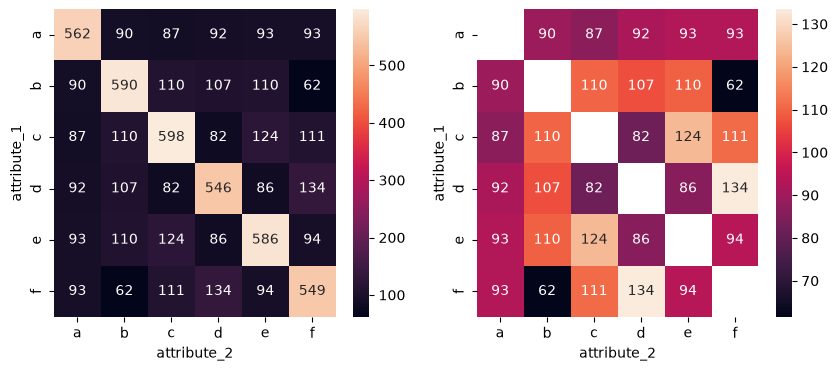

In [20]:
piv = edges.groupby(['attribute_1', 'attribute_2']).size().reset_index().pivot_table(index='attribute_1', columns='attribute_2', values=0, fill_value=0)
piv += piv.T # the list is a -> b, but the graph is undirected, so we need to add the counts for b -> a as well
piv /= 2 # since we added the counts for b -> a, we need to divide by 2 to get the correct counts


fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sns.heatmap(piv, annot=True, fmt="0.0f", ax=ax[0]);

# remove the diagonal values since they are not relevant for the analysis
for attr in piv.index:

    piv.loc[attr, attr] = np.nan
sns.heatmap(piv, annot=True, fmt="0.0f", ax=ax[1]);

We need to create pair of nodes that do not have edges for training purposes. We will create another |E| pairs.

In [76]:
n_edges = len(G.edges)
fictitious_edges = []
for i in range(n_edges):
    # randomly select two nodes
    node_1, node_2 = np.random.choice(G.nodes, 2, replace=False)
    # check if the edge already exists
    while G.has_edge(node_1, node_2) and node_1 != node_2:
        node_1, node_2 = np.random.choice(G.nodes, 2, replace=False)
    fictitious_edges.append((int(node_1), int(node_2), 0))

In [82]:
all_edges_df = pd.DataFrame([(int(u), int(v), 1) for u, v in G.edges] + fictitious_edges, columns=['id1', 'id2', 'is_real'])
all_edges_df['is_real'].value_counts()

is_real
1    6377
0    6377
Name: count, dtype: int64

For each node we will calculate indvidual metrics (e.g. degree, n-lenght neighbors)  
For each pair of nodes, we will calculate relative metrics (e.g. common neighbors, shortest path length)

In [23]:
from networkx.algorithms.approximation import diameter, min_edge_dominating_set, min_weighted_dominating_set, min_maximal_matching


In [57]:
def calc_graph_node_metric(G, metric):
    print(f"Calculating {metric.__name__}...")
    result = metric(G)
    return result

results = {}
metrics = [nx.clustering, nx.betweenness_centrality, nx.closeness_centrality, nx.pagerank, nx.degree_centrality, nx.average_neighbor_degree]
for metric in metrics:
    result = calc_graph_node_metric(G, metric)
    nx.set_node_attributes(G, result, metric.__name__)
    nodes[metric.__name__] = nodes.index.map(result)
    

Calculating clustering...
Calculating betweenness_centrality...
Calculating closeness_centrality...
Calculating pagerank...
Calculating degree_centrality...
Calculating average_neighbor_degree...


In [65]:
from sklearn.model_selection import StratifiedShuffleSplit

In [75]:
all_edges_df

,id1,id2,is_real,attribute_1,average_neighbor_degree_x,clustering_x,betweenness_centrality_x,closeness_centrality_x,pagerank_x,degree_centrality_x,attribute_2,average_neighbor_degree_y,clustering_y,betweenness_centrality_y,closeness_centrality_y,pagerank_y,degree_centrality_y
0,0,49,1,f,12.000000,0.000000,0.000197,0.220845,0.000418,0.002779,a,10.432432,0.042042,0.015323,0.272782,0.002546,0.020567
1,0,10,1,f,12.000000,0.000000,0.000197,0.220845,0.000418,0.002779,f,14.375000,0.000000,0.000614,0.240894,0.000583,0.004447
2,0,155,1,f,12.000000,0.000000,0.000197,0.220845,0.000418,0.002779,f,7.200000,0.000000,0.000228,0.221116,0.000426,0.002779
3,0,1489,1,f,12.000000,0.000000,0.000197,0.220845,0.000418,0.002779,c,12.000000,0.000000,0.000752,0.237931,0.000348,0.002223
4,0,275,1,f,12.000000,0.000000,0.000197,0.220845,0.000418,0.002779,f,9.833333,0.066667,0.000484,0.230228,0.000481,0.003335
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12749,958,486,0,e,15.400000,0.100000,0.000149,0.234918,0.000405,0.002779,e,16.076923,0.102564,0.001919,0.255105,0.000958,0.007226
12750,743,88,0,a,8.100000,0.022222,0.002613,0.251538,0.000797,0.005559,e,14.000000,0.000000,0.000275,0.244662,0.000338,0.002223
12751,690,801,0,c,26.000000,0.000000,0.000126,0.238341,0.000277,0.001668,e,12.833333,0.000000,0.000722,0.235379,0.000517,0.003335
12752,705,1779,0,e,30.666667,0.333333,0.000121,0.243701,0.000268,0.001668,a,18.600000,0.000000,0.001829,0.259222,0.000411,0.002779


In [83]:
all_edges_df = (
    all_edges_df
    .merge(
        nodes.reset_index().rename(columns={'id': 'id1'}),
        on='id1',
        how='left'
    )
    .merge(
        nodes.reset_index().rename(columns={'id': 'id2'}),
        on='id2',
        how='left',
        suffixes=('_1', '_2')
    )
)

In [89]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from sklearn.preprocessing import OneHotEncoder

In [92]:
for train_index, test_index in StratifiedShuffleSplit(n_splits=5, random_state=1, test_size=0.2).split(all_edges_df[['id1', 'id2']], all_edges_df['is_real']):
    train_edges = all_edges_df.iloc[train_index].copy()
    test_edges = all_edges_df.iloc[test_index].copy()
    enc = OneHotEncoder()
    enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

    train_attr = enc.fit_transform(train_edges[['attribute_1', 'attribute_2']])
    test_attr = enc.transform(test_edges[['attribute_1', 'attribute_2']])

    feature_names = enc.get_feature_names_out(['attribute_1', 'attribute_2'])

    train_edges = pd.concat(
        [
            train_edges.drop(columns=['attribute_1', 'attribute_2']),
            pd.DataFrame(train_attr, columns=feature_names, index=train_edges.index)
        ],
        axis=1
    )

    test_edges = pd.concat(
        [
            test_edges.drop(columns=['attribute_1', 'attribute_2']),
            pd.DataFrame(test_attr, columns=feature_names, index=test_edges.index)
        ],
        axis=1
    )

    model = RandomForestClassifier(n_estimators=100, random_state=1)
    model.fit(train_edges.drop(columns=['id1', 'id2', 'is_real']), train_edges['is_real'])
    predictions = model.predict(test_edges.drop(columns=['id1', 'id2', 'is_real']))
    print(accuracy_score(test_edges['is_real'], predictions))
    

0.7616620932967464
0.7745981967855743
0.7573500588004703
0.7534300274402195
0.7471579772638182


In [25]:
nx.attribute_assortativity_coefficient(G, attribute='attribute')

0.44553184358287173

In [26]:
diameter(G)

7

In [27]:
len(min_edge_dominating_set(G))

735

In [28]:
len(min_weighted_dominating_set(G))

233

In [29]:
len(min_maximal_matching(G))

735

In [30]:
G = nx.house_x_graph()

In [31]:
nx.clustering(G)

{0: 1.0, 1: 1.0, 2: 0.6666666666666666, 3: 0.6666666666666666, 4: 1.0}

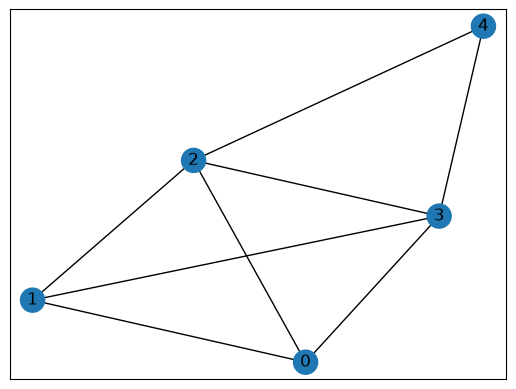

In [32]:
nx.display(G);